In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 7.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
import optuna

# Set random seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Load the dataset
df = pd.read_excel("New Final DataSet Without Sulphur.xlsx", engine='openpyxl')

# Columns to scale after removing 'S'
columns_to_scale = ['N', 'P', 'K', 'pH', 'Temp(°C)', 'Humidity(%)', 'Moisture(%)', 'Rainfall(cm)']

# Scale the numerical features
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Encode the target column
label_encoder = LabelEncoder()
df_scaled['label_encoded'] = label_encoder.fit_transform(df_scaled['Crop'])
df_scaled.drop(columns=['Crop'], inplace=True)

# Split data into features and labels
X = df_scaled.drop(columns=['label_encoded'])
y = df_scaled['label_encoded']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# Reshape features into a grid suitable for CNN
num_features = X_train.shape[1]
grid_size = int(np.ceil(np.sqrt(num_features)))

# Pad or truncate features to fit into grid_size x grid_size
padded_features = grid_size ** 2
X_train_padded = np.pad(X_train.values, ((0, 0), (0, padded_features - num_features)), mode='constant')
X_test_padded = np.pad(X_test.values, ((0, 0), (0, padded_features - num_features)), mode='constant')

X_train_reshaped = X_train_padded.reshape(-1, 1, grid_size, grid_size)
X_test_reshaped = X_test_padded.reshape(-1, 1, grid_size, grid_size)

# Define the Dataset class
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create DataLoader objects
batch_size = 32
train_dataset = TabularDataset(X_train_reshaped, y_train)
test_dataset = TabularDataset(X_test_reshaped, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define the CNN-LSTM model
class CropCNNLSTM(nn.Module):
    def __init__(self, input_shape, num_classes, num_layers, init_channels, kernel_size, lstm_hidden_size, lstm_layers):
        super(CropCNNLSTM, self).__init__()
        self.convs = nn.ModuleList()
        self.pools = nn.ModuleList()
        in_channels = 1
        height, width = input_shape[1], input_shape[2]

        for _ in range(num_layers):
            padding = (kernel_size - 1) // 2
            self.convs.append(nn.Conv2d(in_channels, init_channels, kernel_size, padding=padding))
            self.pools.append(nn.MaxPool2d(2))
            in_channels = init_channels
            init_channels *= 2

            height = (height - kernel_size + 2 * padding) + 1
            width = (width - kernel_size + 2 * padding) + 1
            height = height // 2
            width = width // 2

            if height <= 1 or width <= 1:
                break

        self.flattened_size = in_channels * height * width
        self.lstm = nn.LSTM(input_size=self.flattened_size, hidden_size=lstm_hidden_size,
                            num_layers=lstm_layers, batch_first=True)
        self.fc = nn.Linear(lstm_hidden_size, num_classes)

    def forward(self, x):
        for conv, pool in zip(self.convs, self.pools):
            x = F.relu(conv(x))
            x = pool(x)

        batch_size = x.size(0)
        x = x.view(batch_size, 1, -1)  # Flatten and reshape for LSTM
        x, _ = self.lstm(x)
        x = x[:, -1, :]  # Take the last LSTM output
        x = self.fc(x)
        return x

# Define the Optuna objective function
def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 5)
    init_channels = trial.suggest_int("init_channels", 16, 64, step=16)
    kernel_size = trial.suggest_int("kernel_size", 2, 3)
    lstm_hidden_size = trial.suggest_int("lstm_hidden_size", 64, 256, step=64)
    lstm_layers = trial.suggest_int("lstm_layers", 1, 3)
    learning_rate = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    epochs = trial.suggest_int("epochs", 5, 30)

    model = CropCNNLSTM(
        input_shape=(1, grid_size, grid_size),
        num_classes=len(label_encoder.classes_),
        num_layers=num_layers,
        init_channels=init_channels,
        kernel_size=kernel_size,
        lstm_hidden_size=lstm_hidden_size,
        lstm_layers=lstm_layers
    )
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=learning_rate)

    # Training Loop
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    accuracy = correct / total
    return accuracy

# Run Optuna Optimization
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

# Print Best Hyperparameters
print("Best hyperparameters:", study.best_params)


Best hyperparameters: {'num_layers': 4, 'init_channels': 16, 'kernel_size': 3, 'lstm_hidden_size': 64, 'lstm_layers': 1, 'lr': 0.0033640580511635804, 'epochs': 26}


In [ ]:
Best hyperparameters: {'num_layers': 4, 'init_channels': 16, 'kernel_size': 3, 'lstm_hidden_size': 64, 'lstm_layers': 1, 'lr': 0.009937635470548512, 'epochs': 24}

SyntaxError: invalid syntax (<ipython-input-3-5958ae3667ea>, line 1)

Epoch with highest test accuracy: 25
Train Accuracy: 0.9019
Test Accuracy: 0.9152
Train Precision: 0.9180
Train Recall: 0.9095
Train F1-Score: 0.9088
Test Precision: 0.9009
Test Recall: 0.8894
Test F1-Score: 0.8902


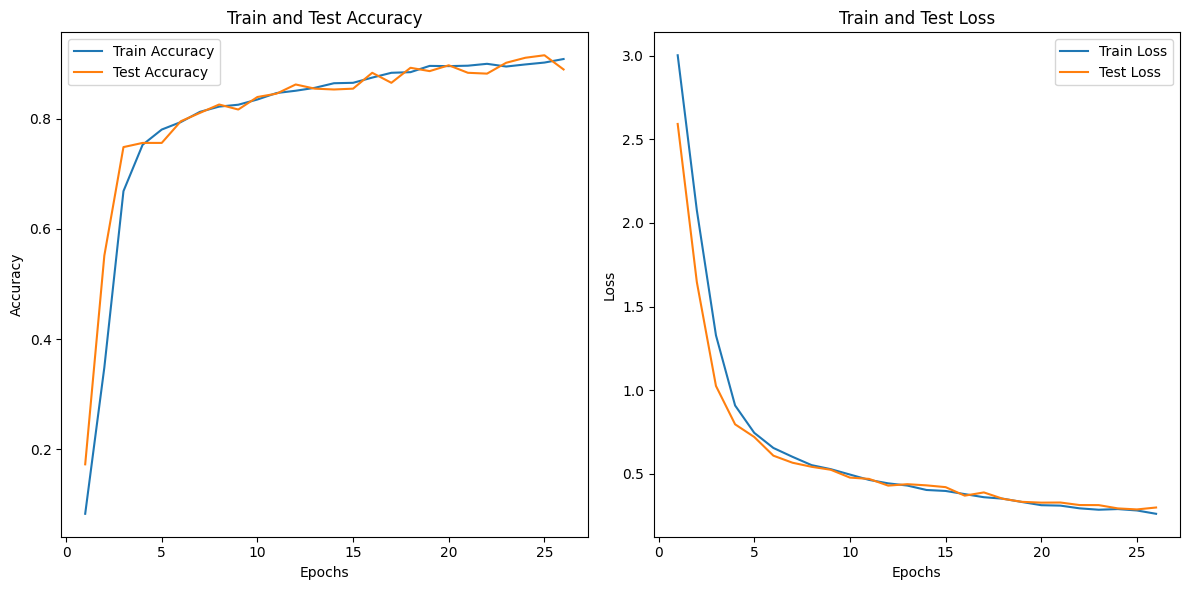

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Define the best hyperparameters
best_params ={'num_layers': 4, 'init_channels': 16, 'kernel_size': 3, 'lstm_hidden_size': 64, 'lstm_layers': 1, 'lr': 0.0033640580511635804, 'epochs': 26}

# Instantiate the model with the best parameters
model = CropCNNLSTM(input_shape=(1, 3, 3), num_classes=len(label_encoder.classes_),
                    num_layers=best_params['num_layers'], init_channels=best_params['init_channels'],
                    kernel_size=best_params['kernel_size'], lstm_hidden_size=best_params['lstm_hidden_size'],
                    lstm_layers=best_params['lstm_layers'])
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=best_params['lr'])

# Track metrics
train_accuracies = []
test_accuracies = []
train_losses = []
test_losses = []

# Training Loop
for epoch in range(best_params['epochs']):
    model.train()
    train_correct = 0
    train_total = 0
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.view(-1, 1, 3, 3)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    train_accuracy = train_correct / train_total
    train_accuracies.append(train_accuracy)
    train_losses.append(running_train_loss / len(train_loader))

    # Validation
    model.eval()
    test_correct = 0
    test_total = 0
    running_test_loss = 0.0
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.view(-1, 1, 3, 3)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            test_total += y_batch.size(0)
            test_correct += (predicted == y_batch).sum().item()
            all_targets.extend(y_batch.tolist())
            all_predictions.extend(predicted.tolist())

    test_accuracy = test_correct / test_total
    test_accuracies.append(test_accuracy)
    test_losses.append(running_test_loss / len(test_loader))

# Identify epoch with highest test accuracy
best_epoch = test_accuracies.index(max(test_accuracies))

# Compute metrics for the best epoch
model.eval()
train_predictions, train_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.view(-1, 1, 3, 3)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        train_predictions.extend(predicted.tolist())
        train_targets.extend(y_batch.tolist())

train_precision = precision_score(train_targets, train_predictions, average="macro")
train_recall = recall_score(train_targets, train_predictions, average="macro")
train_f1 = f1_score(train_targets, train_predictions, average="macro")

test_precision = precision_score(all_targets, all_predictions, average="macro")
test_recall = recall_score(all_targets, all_predictions, average="macro")
test_f1 = f1_score(all_targets, all_predictions, average="macro")

# Print metrics
print(f"Epoch with highest test accuracy: {best_epoch + 1}")
print(f"Train Accuracy: {train_accuracies[best_epoch]:.4f}")
print(f"Test Accuracy: {test_accuracies[best_epoch]:.4f}")
print(f"Train Precision: {train_precision:.4f}")
print(f"Train Recall: {train_recall:.4f}")
print(f"Train F1-Score: {train_f1:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

# Plot accuracy and loss
epochs = range(1, best_params['epochs'] + 1)

plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.title('Train and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.title('Train and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('cnnlstm.png', transparent=True)

plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Classification report for train data
train_report = classification_report(train_targets, train_predictions, target_names=label_encoder.classes_, digits=3)
print("Train Classification Report:\n", train_report)

# Classification report for test data
test_report = classification_report(all_targets, all_predictions, target_names=label_encoder.classes_, digits=3)
print("Test Classification Report:\n", test_report)


Train Classification Report:
                   precision    recall  f1-score   support

       Aman Rice      0.544     0.825     0.656       120
       Aush Rice      0.917     0.825     0.868       120
            Bean      0.877     0.775     0.823       120
       Boro Rice      0.844     0.450     0.587       120
        Calabash      1.000     0.992     0.996       120
     Cauliflower      1.000     0.992     0.996       120
Colocasia leaves      0.905     0.950     0.927       120
            Corn      0.810     0.958     0.878       120
        Eggplant      0.940     0.917     0.928       120
            Jute      0.982     0.900     0.939       120
       Leafy Veg      0.875     0.933     0.903       120
        Oil crop      0.926     0.833     0.877       120
           Onion      0.984     1.000     0.992       120
          Papaya      1.000     1.000     1.000       120
          Peanut      0.802     0.842     0.821       120
       Pineapple      1.000     1.000    

Model Size: 0.09 MB
Number of Trainable Parameters: 22582
Average Training Time Per Epoch: 0.41 seconds
Epoch with highest test accuracy: 14
Train Accuracy: 0.8973
Test Accuracy: 0.9000
Train Precision: 0.9058
Train Recall: 0.9000
Train F1-Score: 0.8978
Test Precision: 0.8950
Test Recall: 0.8864
Test F1-Score: 0.8864


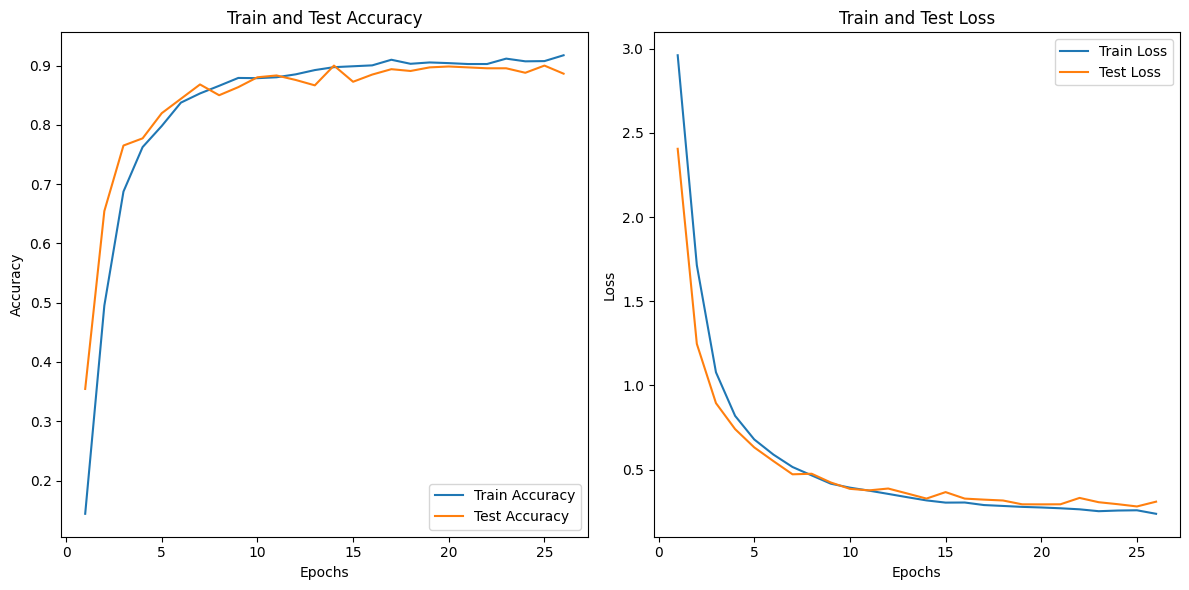

In [ ]:
import os
import time
import torch
import torch.nn as nn
from torch.optim import Adam
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
best_params = {
    'num_layers': 4,
    'init_channels': 16,
    'kernel_size': 3,
    'lstm_hidden_size': 64,
    'lstm_layers': 1,
    'lr': 0.0033640580511635804,
    'epochs': 26
}

# Model initialization
model = CropCNNLSTM(input_shape=(1, 3, 3), num_classes=len(label_encoder.classes_),
                    num_layers=best_params['num_layers'], init_channels=best_params['init_channels'],
                    kernel_size=best_params['kernel_size'], lstm_hidden_size=best_params['lstm_hidden_size'],
                    lstm_layers=best_params['lstm_layers'])

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=best_params['lr'])

# Metrics storage
train_accuracies = []
test_accuracies = []
train_losses = []
test_losses = []
epoch_times = []

# Training Loop
for epoch in range(best_params['epochs']):
    start_time = time.time()

    model.train()
    train_correct = 0
    train_total = 0
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.view(-1, 1, 3, 3)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    train_accuracy = train_correct / train_total
    train_accuracies.append(train_accuracy)
    train_losses.append(running_train_loss / len(train_loader))

    # Validation
    model.eval()
    test_correct = 0
    test_total = 0
    running_test_loss = 0.0
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.view(-1, 1, 3, 3)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            test_total += y_batch.size(0)
            test_correct += (predicted == y_batch).sum().item()
            all_targets.extend(y_batch.tolist())
            all_predictions.extend(predicted.tolist())

    test_accuracy = test_correct / test_total
    test_accuracies.append(test_accuracy)
    test_losses.append(running_test_loss / len(test_loader))

    end_time = time.time()
    epoch_times.append(end_time - start_time)

# Best epoch
best_epoch = test_accuracies.index(max(test_accuracies))

# Metrics for best epoch
model.eval()
train_predictions, train_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.view(-1, 1, 3, 3)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        train_predictions.extend(predicted.tolist())
        train_targets.extend(y_batch.tolist())

train_precision = precision_score(train_targets, train_predictions, average="macro")
train_recall = recall_score(train_targets, train_predictions, average="macro")
train_f1 = f1_score(train_targets, train_predictions, average="macro")

test_precision = precision_score(all_targets, all_predictions, average="macro")
test_recall = recall_score(all_targets, all_predictions, average="macro")
test_f1 = f1_score(all_targets, all_predictions, average="macro")

# Model size and parameters
torch.save(model.state_dict(), "temp_model.pth")
model_size = os.path.getsize("temp_model.pth") / (1024 ** 2)  # MB
os.remove("temp_model.pth")
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
avg_epoch_time = sum(epoch_times) / len(epoch_times)

# Print results
print(f"Model Size: {model_size:.2f} MB")
print(f"Number of Trainable Parameters: {num_params}")
print(f"Average Training Time Per Epoch: {avg_epoch_time:.2f} seconds")
print(f"Epoch with highest test accuracy: {best_epoch + 1}")
print(f"Train Accuracy: {train_accuracies[best_epoch]:.4f}")
print(f"Test Accuracy: {test_accuracies[best_epoch]:.4f}")
print(f"Train Precision: {train_precision:.4f}")
print(f"Train Recall: {train_recall:.4f}")
print(f"Train F1-Score: {train_f1:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

# Plot accuracy and loss
epochs = range(1, best_params['epochs'] + 1)

plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.title('Train and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.title('Train and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('cnnlstm.png', transparent=True)
plt.show()